In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [67]:
df = pd.read_csv('academIQ_clean_dataset_v4.csv').drop_duplicates()

# Feature Engineering
df['avg_daily_time'] = df['total_time_spent'] / (df['active_days'] + 1)
df['clicks_per_day'] = df['all_clicks'] / (df['active_days'] + 1)

# Log Transformation for skewed data
skewed_cols = ['all_clicks', 'material_clicks', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Select Features
feature_cols = ['all_clicks', 'active_days', 'access_frequency', 'material_clicks',
                'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
                'assignment_submissions', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']

X = df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

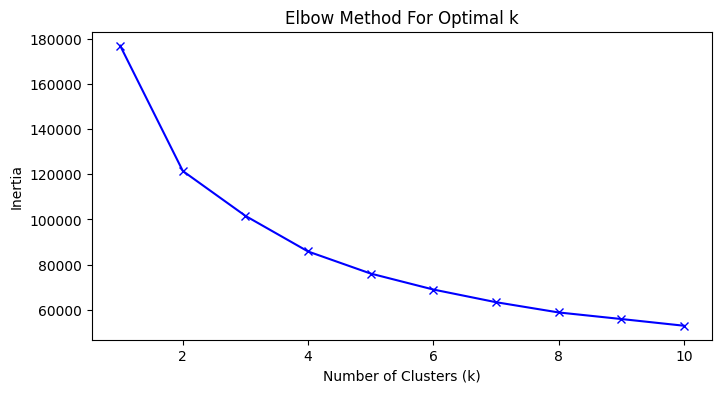

In [68]:
#ELBOW METHOD ---
inertia = []
K_range = range(1, 11)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Visualize the Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [69]:
# Generate Clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['risk_cluster'] = kmeans.fit_predict(X_scaled)


# Split Data for Classification
y_cluster = df['risk_cluster']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_cluster, test_size=0.2, random_state=42)

# Train Classifier
cluster_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.01, max_depth=5, subsample=0.8, random_state=42
)
cluster_model.fit(X_train_c, y_train_c)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=42, subsample=0.8)

In [73]:
# This will show you exactly how many students are in each cluster
print(df['risk_cluster'].value_counts())

risk_cluster
2    5363
1    5122
3    3164
0    2440
Name: count, dtype: int64


In [74]:
# Evaluate Classifier
print(f"Accuracy: {accuracy_score(y_test_c, cluster_model.predict(X_test_c)):.2%}")

Accuracy: 96.08%


In [75]:
# Helper function to map score to letter (Your Logic)
def map_grade(score):
    if score > 85: return "A"
    elif score >= 70: return "B"
    elif score >= 55: return "C"
    elif score >= 50: return "D"
    else: return "F"

In [76]:
# Target is final_grade
y_grade = df['final_grade']
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_scaled, y_grade, test_size=0.2, random_state=42)

# Train Regressor (Predicts a number 0-100)
grade_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
grade_model.fit(X_train_g, y_train_g)

# Evaluate Regressor
grade_preds = grade_model.predict(X_test_g)
mae = mean_absolute_error(y_test_g, grade_preds)

In [77]:
# 1. Calculate R-Squared
r2 = r2_score(y_test_g, grade_preds)
# 2. Calculate Accuracy
mask = y_test_g != 0  # Filtering out 0 grades to avoid division error
mape = np.mean(np.abs((y_test_g[mask] - grade_preds[mask]) / y_test_g[mask]))
accuracy = 1 - mape
# 3. Print
print(f"Model Statistical Fit (R²): {r2:.2%}")
print(f"Prediction Accuracy:        {accuracy:.2%}")
print(f"Example: Real Grade: {y_test_g.iloc[0]}, Predicted: {grade_preds[0]:.1f}")

Model Statistical Fit (R²): 56.92%
Prediction Accuracy:        79.46%
Example: Real Grade: 30, Predicted: 34.0


In [78]:
import joblib
# Save models and the scaler
joblib.dump(cluster_model, 'academIQ_cluster_model.pkl')
joblib.dump(grade_model, 'academIQ_grade_model.pkl')
joblib.dump(scaler, 'academIQ_scaler.pkl')

['academIQ_scaler.pkl']